## Parte 1: Regressão Linear

In [45]:
import os
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [46]:

# Gerando dados fictícios
np.random.seed(42)
num_quartos = np.random.randint(1, 6, 100)
metragem_quadrada = np.random.randint(50, 200, 100)
preco_imovel = (num_quartos * 10000) + (metragem_quadrada * 50) + np.random.randint(5000, 20000, 100)

df = pd.DataFrame({
    'Numero_Quartos': num_quartos,
    'Metragem_Quadrada': metragem_quadrada,
    'Preco_Imovel': preco_imovel
})
display(df.head())

,Numero_Quartos,Metragem_Quadrada,Preco_Imovel
0,4,77,50836
1,5,184,78022
2,3,121,49388
3,5,61,69461
4,5,82,62011


In [47]:
# Dividindo os dados
X = df[['Numero_Quartos', 'Metragem_Quadrada']]
y = df['Preco_Imovel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dados divididos em conjuntos de treinamento e teste.")

Dados divididos em conjuntos de treinamento e teste.


In [48]:
# Modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X_train, y_train)
predicoes = modelo.predict(X_test)

print("Modelo de regressão linear treinado e previsões geradas.")

Modelo de regressão linear treinado e previsões geradas.


In [49]:
# Avaliação do modelo
mse = mean_squared_error(y_test, predicoes)
r2 = r2_score(y_test, predicoes)
print(f'Erro Médio Quadrático (MSE): {mse}')
print(f'Coeficiente de Determinação (R²): {r2}')

Erro Médio Quadrático (MSE): 20924394.13708526
Coeficiente de Determinação (R²): 0.9251464070813848


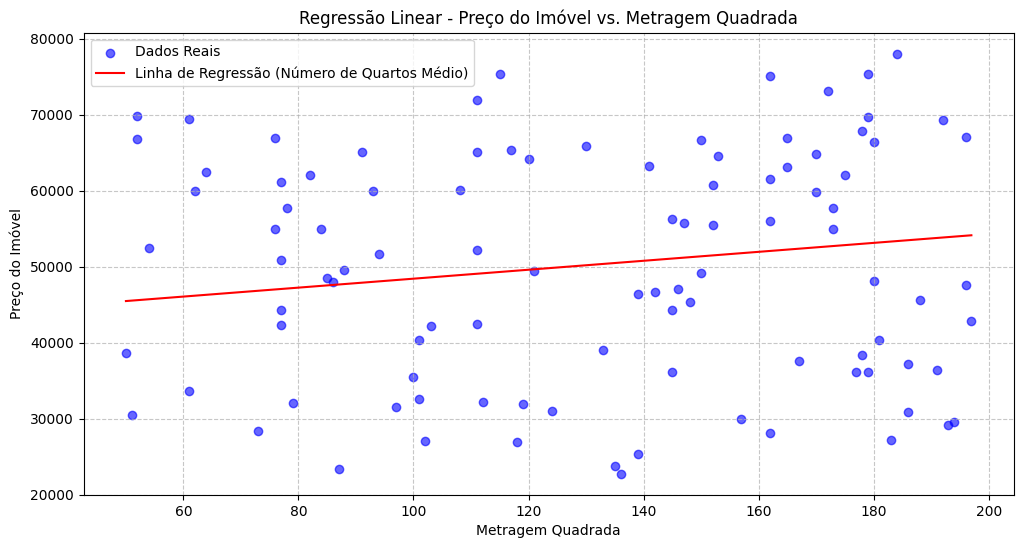

In [50]:
# Visualização
plt.figure(figsize=(12, 6))
plt.scatter(df['Metragem_Quadrada'], df['Preco_Imovel'], color='blue', label='Dados Reais', alpha=0.6)

# Para a linha de regressão, precisamos prever para um range contínuo de metragem quadrada
# e manter o número de quartos constante (ou usar uma média/mediana para visualização 2D)
# Para simplificar a visualização, vamos usar o X_test para traçar a linha de regressão
# Isso é uma simplificação para fins de plotagem 2D do modelo multi-variável

# Criando um range para Metragem_Quadrada para a linha de regressão
# Vamos assumir um número médio de quartos para visualizar a relação 2D
metragem_min = df['Metragem_Quadrada'].min()
metragem_max = df['Metragem_Quadrada'].max()
metragem_range = np.linspace(metragem_min, metragem_max, 100).reshape(-1, 1)

# Assumir o número médio de quartos para prever
num_quartos_mean = df['Numero_Quartos'].mean()
X_plot = pd.DataFrame({'Numero_Quartos': [num_quartos_mean] * 100, 'Metragem_Quadrada': metragem_range.flatten()})

# A linha de regressão com o modelo treinado
plt.plot(X_plot['Metragem_Quadrada'], modelo.predict(X_plot), color='red', label='Linha de Regressão (Número de Quartos Médio)')

plt.title('Regressão Linear - Preço do Imóvel vs. Metragem Quadrada')
plt.xlabel('Metragem Quadrada')
plt.ylabel('Preço do Imóvel')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Parte 2: Regressão Logística

In [51]:

# Gerando dados fictícios
np.random.seed(42)
idade = np.random.randint(18, 70, 200)
renda = np.random.randint(20000, 100000, 200)

# Ajuste para tornar a 'Renda' mais influente no 'Clicou_Anuncio'
# Clientes com renda mais alta têm maior probabilidade de clicar
prob_clique = 1 / (1 + np.exp(-(0.00005 * renda - 3)))
clicou_anuncio = (np.random.rand(200) < prob_clique).astype(int)

df_log = pd.DataFrame({
    'Idade': idade,
    'Renda': renda,
    'Clicou_Anuncio': clicou_anuncio
})
display(df_log.head())

,Idade,Renda,Clicou_Anuncio
0,56,78053,0
1,69,41959,0
2,46,25530,0
3,32,23748,0
4,60,33545,0


In [52]:
# Dividindo os dados
X_log = df_log[['Idade', 'Renda']]
y_log = df_log['Clicou_Anuncio']
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

print("Dados logísticos divididos em conjuntos de treinamento e teste.")

Dados logísticos divididos em conjuntos de treinamento e teste.


In [53]:
# Modelo de regressão logística
modelo_logistico = LogisticRegression(solver='liblinear', random_state=42)
modelo_logistico.fit(X_train_log, y_train_log)
predicoes_log = modelo_logistico.predict(X_test_log)

print("Modelo de regressão logística treinado e previsões geradas.")

Modelo de regressão logística treinado e previsões geradas.


In [54]:
# Avaliação do modelo
accuracy = accuracy_score(y_test_log, predicoes_log)
precision = precision_score(y_test_log, predicoes_log, zero_division=0)
recall = recall_score(y_test_log, predicoes_log, zero_division=0)
f1 = f1_score(y_test_log, predicoes_log, zero_division=0)

print(f'Acurácia: {accuracy:.4f}')
print(f'Precisão: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Pontuação F1: {f1:.4f}')
print(f'\nMatriz de Confusão:\n{confusion_matrix(y_test_log, predicoes_log)}')
print(f'\nRelatório de Classificação:\n{classification_report(y_test_log, predicoes_log, zero_division=0)}')

Acurácia: 0.8000
Precisão: 0.7000
Recall: 0.8750
Pontuação F1: 0.7778

Matriz de Confusão:
[[18  6]
 [ 2 14]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82        24
           1       0.70      0.88      0.78        16

    accuracy                           0.80        40
   macro avg       0.80      0.81      0.80        40
weighted avg       0.82      0.80      0.80        40



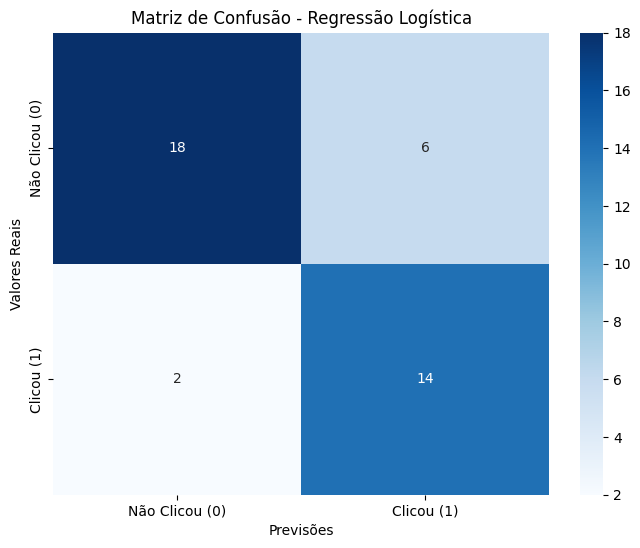

In [55]:
# Visualização da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_log, predicoes_log), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Clicou (0)', 'Clicou (1)'],
            yticklabels=['Não Clicou (0)', 'Clicou (1)'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()

In [56]:

# -------------------------------
# Dados fictícios para imóveis
# -------------------------------
np.random.seed(42)
num_quartos = np.random.randint(1, 6, 100)
metragem_quadrada = np.random.randint(50, 200, 100)
preco_imovel = (num_quartos * 10000) + (metragem_quadrada * 50) + np.random.randint(5000, 20000, 100)

df_imoveis = pd.DataFrame({
    'Numero_Quartos': num_quartos,
    'Metragem_Quadrada': metragem_quadrada,
    'Preco_Imovel': preco_imovel
})

# Salvando em CSV
df_imoveis.to_csv("dados_imoveis.csv", index=False)
print("Arquivo 'dados_imoveis.csv' criado com sucesso!")

# -------------------------------
# Dados fictícios para anúncios
# -------------------------------
idade = np.random.randint(18, 70, 200)
renda = np.random.randint(20000, 100000, 200)
clicou_anuncio = np.random.choice([0, 1], size=200, p=[0.7, 0.3])

df_anuncios = pd.DataFrame({
    'Idade': idade,
    'Renda': renda,
    'Clicou_Anuncio': clicou_anuncio
})

# Salvando em CSV
df_anuncios.to_csv("dados_anuncios.csv", index=False)
print("Arquivo 'dados_anuncios.csv' criado com sucesso!")


Arquivo 'dados_imoveis.csv' criado com sucesso!
Arquivo 'dados_anuncios.csv' criado com sucesso!


In [57]:
# gera_vendas_simulado_calibrado.py
# Gera um CSV com 1000 linhas no mesmo padrão de vendas.csv (Meses,Vendas,Eventos).
# Se houver um arquivo 'vendas.csv' no mesmo diretório, o script usa suas estatísticas para calibrar a geração.



SEED = 42
np.random.seed(SEED)
random.seed(SEED)

INPUT_FILE = "vendas.csv"          # arquivo original (opcional)
OUTPUT_FILE = "vendas_simulado_1000.csv"
N = 1000

# Parâmetros padrão (aproximados a partir do exemplo fornecido)
DEFAULT_MEAN = 200.0
DEFAULT_STD = 60.0
DEFAULT_MIN = 50.0
DEFAULT_MAX = 320.0
DEFAULT_P_EVENTO = 0.48
CYCLE_MONTHS = 24  # repetir 1..24 para preservar sazonalidade

def calibrate_from_file(path):
    try:
        df = pd.read_csv(path)
        # Espera colunas Meses,Vendas,Eventos
        if "Vendas" in df.columns and "Eventos" in df.columns:
            vendas = df["Vendas"].astype(float)
            eventos = df["Eventos"].astype(int)
            mean = vendas.mean()
            std = vendas.std(ddof=0)
            vmin = max(vendas.min(), 0.0)
            vmax = vendas.max()
            p_evento = eventos.mean()
            # Ajustes mínimos para evitar extremos
            std = max(std, 1.0)
            return {
                "mean": float(mean),
                "std": float(std),
                "min": float(vmin),
                "max": float(vmax),
                "p_evento": float(p_evento)
            }
    except Exception:
        pass
    return None

def sample_vendas_trunc_normal(mean, std, vmin, vmax):
    # Amostra de normal truncada (re-tenta até cair no intervalo)
    while True:
        v = np.random.normal(loc=mean, scale=std)
        if vmin <= v <= vmax:
            return round(float(v), 2)

def main():
    params = calibrate_from_file(INPUT_FILE)
    if params is None:
        params = {
            "mean": DEFAULT_MEAN,
            "std": DEFAULT_STD,
            "min": DEFAULT_MIN,
            "max": DEFAULT_MAX,
            "p_evento": DEFAULT_P_EVENTO
        }
        print(f"Nenhum '{INPUT_FILE}' encontrado ou leitura falhou. Usando parâmetros padrão.")
    else:
        print(f"Parâmetros calibrados a partir de '{INPUT_FILE}': mean={params['mean']:.2f}, std={params['std']:.2f}, min={params['min']:.2f}, max={params['max']:.2f}, p_evento={params['p_evento']:.3f}")

    with open(OUTPUT_FILE, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Meses", "Vendas", "Eventos"])
        for i in range(N):
            # Meses em ciclo 1..CYCLE_MONTHS
            meses = (i % CYCLE_MONTHS) + 1
            vendas = sample_vendas_trunc_normal(params["mean"], params["std"], params["min"], params["max"])
            evento = 1 if random.random() < params["p_evento"] else 0
            writer.writerow([meses, f"{vendas:.2f}", evento])

    print(f"Arquivo gerado: {OUTPUT_FILE} ({N} linhas + cabeçalho)")

if __name__ == "__main__":
    main()


Parâmetros calibrados a partir de 'vendas.csv': mean=198.89, std=53.75, min=51.70, max=317.88, p_evento=0.461
Arquivo gerado: vendas_simulado_1000.csv (1000 linhas + cabeçalho)


In [58]:


def gerar_csv_imoveis(path="dados_imoveis_precisos.csv",
                      n_samples=500,
                      seed=42,
                      coef_quartos=12000,
                      coef_m2=80,
                      base_price=30000,
                      noise_std=5000,
                      add_outliers=True,
                      outlier_fraction=0.02):
    """
    Gera um CSV com relação linear forte entre Numero_Quartos, Metragem_Quadrada e Preco_Imovel.
    Parâmetros ajustáveis para controlar coeficientes e ruído.
    """
    np.random.seed(seed)

    # Numero de quartos: 1 a 6, distribuição realista (mais 2-3 quartos)
    num_quartos = np.random.choice([1,2,3,4,5,6], size=n_samples, p=[0.05,0.25,0.35,0.2,0.1,0.05])

    # Metragem: correlacionada com numero de quartos + variação
    metragem_base = num_quartos * np.random.uniform(25, 40, size=n_samples)  # cada quarto adiciona 25-40 m2
    metragem_ruido = np.random.normal(loc=0, scale=8, size=n_samples)
    metragem_quadrada = np.round(np.clip(metragem_base + metragem_ruido, 30, 400)).astype(int)

    # Preço: combinação linear forte + pequeno ruído Gaussiano
    preco_sem_ruido = base_price + coef_quartos * num_quartos + coef_m2 * metragem_quadrada
    ruido = np.random.normal(loc=0, scale=noise_std, size=n_samples)
    preco_imovel = np.round(np.maximum(preco_sem_ruido + ruido, 10000)).astype(int)

    df = pd.DataFrame({
        "Numero_Quartos": num_quartos,
        "Metragem_Quadrada": metragem_quadrada,
        "Preco_Imovel": preco_imovel
    })

    # Opcional: adicionar alguns outliers para realismo (poucos)
    if add_outliers and outlier_fraction > 0:
        n_out = max(1, int(n_samples * outlier_fraction))
        out_idx = np.random.choice(df.index, size=n_out, replace=False)
        # Aumenta ou diminui preço drasticamente em alguns casos
        df.loc[out_idx, "Preco_Imovel"] = (df.loc[out_idx, "Preco_Imovel"] *
                                           np.random.choice([0.6, 1.6], size=n_out)).astype(int)

    df.to_csv(path, index=False)
    print(f"Arquivo '{path}' criado com {n_samples} amostras.")
    return df

if __name__ == "__main__":
    # Exemplo de uso: gera CSV com 500 amostras e ruído pequeno
    gerar_csv_imoveis(path="dados_imoveis_precisos.csv",
                      n_samples=500,
                      seed=42,
                      coef_quartos=12000,
                      coef_m2=80,
                      base_price=30000,
                      noise_std=4000,
                      add_outliers=True,
                      outlier_fraction=0.02)


Arquivo 'dados_imoveis_precisos.csv' criado com 500 amostras.


Erro Médio Quadrático (MSE): 20924394.13708526
Coeficiente de Determinação (R²): 0.9251464070813848


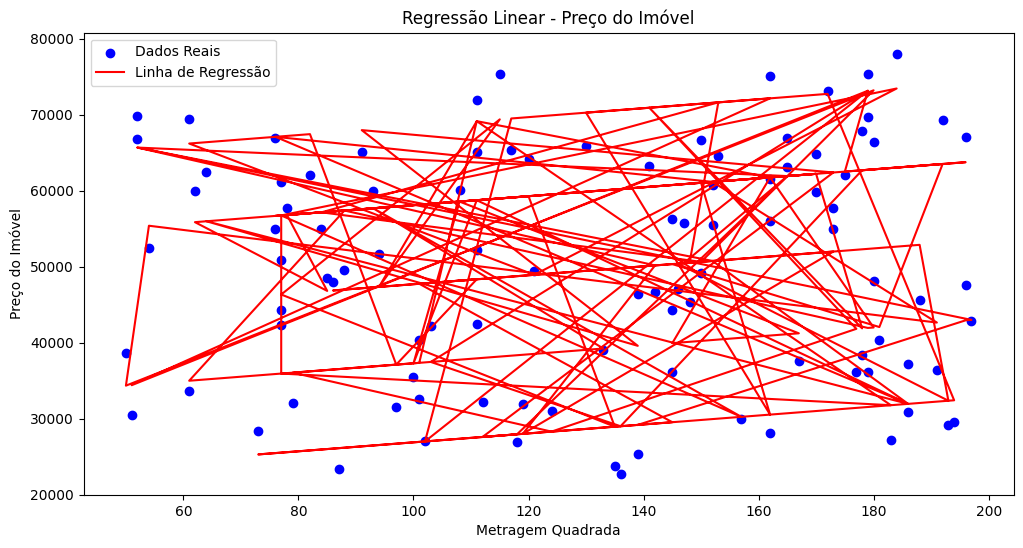

In [59]:


# Lendo o CSV
df = pd.read_csv("dados_imoveis.csv")

# Dividindo os dados
X = df[['Numero_Quartos', 'Metragem_Quadrada']]
y = df['Preco_Imovel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)
predicoes = modelo.predict(X_test)

# Avaliação
mse = mean_squared_error(y_test, predicoes)
r2 = r2_score(y_test, predicoes)
print(f"Erro Médio Quadrático (MSE): {mse}")
print(f"Coeficiente de Determinação (R²): {r2}")

# Visualização
plt.figure(figsize=(12, 6))
plt.scatter(df['Metragem_Quadrada'], df['Preco_Imovel'], color='blue', label='Dados Reais')
plt.plot(df['Metragem_Quadrada'], modelo.predict(df[['Numero_Quartos', 'Metragem_Quadrada']]), color='red', label='Linha de Regressão')
plt.title('Regressão Linear - Preço do Imóvel')
plt.xlabel('Metragem Quadrada')
plt.ylabel('Preço do Imóvel')
plt.legend()
plt.show()


MSE: 30412499.49  R²: 0.9148


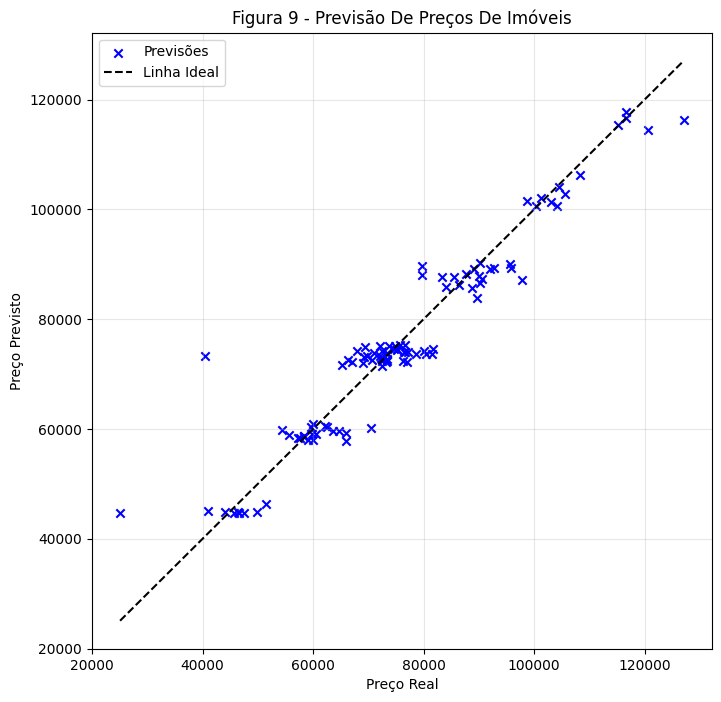

In [60]:


# Ler o CSV gerado
df = pd.read_csv("dados_imoveis_precisos.csv")

X = df[["Numero_Quartos", "Metragem_Quadrada"]]
y = df["Preco_Imovel"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}  R²: {r2:.4f}")

# Plot Preço Real vs Preço Previsto (semelhante à imagem)
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, marker='x', color='blue', label='Previsões')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black', label='Linha Ideal')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Figura 9 - Previsão De Preços De Imóveis')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Precisão: 0.0
Recall: 0.0
Pontuação F1: 0.0
Acurácia: 0.7
Matriz de Confusão:
[[28  0]
 [12  0]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        28
           1       0.00      0.00      0.00        12

    accuracy                           0.70        40
   macro avg       0.35      0.50      0.41        40
weighted avg       0.49      0.70      0.58        40



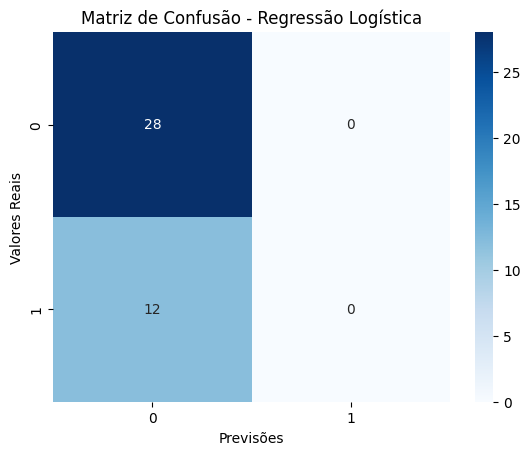

In [61]:

# Lendo o CSV
df_log = pd.read_csv("dados_anuncios.csv")

# Dividindo os dados
X_log = df_log[['Idade', 'Renda']]
y_log = df_log['Clicou_Anuncio']
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Modelo
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_log, y_train_log)
predicoes_log = modelo_logistico.predict(X_test_log)

# Avaliação
accuracy = accuracy_score(y_test_log, predicoes_log)
precision = precision_score(y_test_log, predicoes_log)
recall = recall_score(y_test_log, predicoes_log)
f1 = f1_score(y_test_log, predicoes_log)

print(f"Precisão: {precision}")
print(f"Recall: {recall}")
print(f"Pontuação F1: {f1}")
print(f"Acurácia: {accuracy}")
print(f"Matriz de Confusão:\n{confusion_matrix(y_test_log, predicoes_log)}")
print(f"Relatório de Classificação:\n{classification_report(y_test_log, predicoes_log)}")

# Visualização da matriz de confusão
sns.heatmap(confusion_matrix(y_test_log, predicoes_log), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()
